# 가명처리

In [1]:
import pandas as pd

pd.set_option('display.max_rows',100)
pd.set_option('display.min_rows',None)

# 파일 로딩

df_org=pd.read_csv ("data_org.csv", encoding="cp949", dtype={"식별번호":str , "성별": str, "우편번호":str})
df_org
#식별번호, 성별, 나이, 우편번호, 대출금, 연체금 등의 정보

# 1) 우편번호 범주화
# 2) 대출금액 상하단코딩 : 상하의 극소수의 데이터는 액수 자체가 너무 독특해서 구별이 가능하므로 상하단 코딩
  # 특전 금액 이상 혹은 하단은 묶음

,식별번호,성별,나이,우편번호,가입기간,대출건수,문의건수,보유계좌수,연체금액,대출금액,예금잔액,적금잔액
0,56586729,2,62,53015,11,3,9,3,0,247,43,264
1,82351459,2,35,52319,12,5,10,2,0,335,40,113
2,89060200,2,10,04534,10,3,5,5,0,33,20,30
3,21151877,1,51,41535,10,3,8,8,0,128,27,214
4,76275783,2,67,38186,11,3,8,1,0,33,28,265
5,56315627,2,55,04534,10,3,5,5,0,33,20,30
6,34674716,2,53,06627,11,3,8,1,0,595,115,293
7,33851109,1,39,06797,10,3,10,5,59,367,45,203
8,87812632,1,43,11922,10,3,6,11,0,33,125,135
9,10772216,2,52,35212,12,5,12,2,0,233,22,211


In [2]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18922 entries, 0 to 18921
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   식별번호    18922 non-null  object
 1   성별      18922 non-null  object
 2   나이      18922 non-null  int64 
 3   우편번호    18922 non-null  object
 4   가입기간    18922 non-null  int64 
 5   대출건수    18922 non-null  int64 
 6   문의건수    18922 non-null  int64 
 7   보유계좌수   18922 non-null  int64 
 8   연체금액    18922 non-null  int64 
 9   대출금액    18922 non-null  int64 
 10  예금잔액    18922 non-null  int64 
 11  적금잔액    18922 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 1.7+ MB


## 식별자 삭제

In [3]:
# 1. 원본은 혹시 모르니 그대로 두고 (df_org)
# 2. 가명처리 작업용 복사본 (df)
df = df_org.copy()

# 식별자 삭제 (개인 특정이 가능한 정보)
del df["식별번호"]
df


,성별,나이,우편번호,가입기간,대출건수,문의건수,보유계좌수,연체금액,대출금액,예금잔액,적금잔액
0,2,62,53015,11,3,9,3,0,247,43,264
1,2,35,52319,12,5,10,2,0,335,40,113
2,2,10,04534,10,3,5,5,0,33,20,30
3,1,51,41535,10,3,8,8,0,128,27,214
4,2,67,38186,11,3,8,1,0,33,28,265
5,2,55,04534,10,3,5,5,0,33,20,30
6,2,53,06627,11,3,8,1,0,595,115,293
7,1,39,06797,10,3,10,5,59,367,45,203
8,1,43,11922,10,3,6,11,0,33,125,135
9,2,52,35212,12,5,12,2,0,233,22,211


## 범주화

In [4]:
print ("원본\n", df_org['우편번호'][:10])

df['우편번호']=df['우편번호'].apply( lambda x : x[:3]+"**")
print ("\n마스킹후\n", df['우편번호'][:10])

# 범주 데이터 
df.우편번호.value_counts()

원본
 0    53015
1    52319
2    04534
3    41535
4    38186
5    04534
6    06627
7    06797
8    11922
9    35212
Name: 우편번호, dtype: object

마스킹후
 0    530**
1    523**
2    045**
3    415**
4    381**
5    045**
6    066**
7    067**
8    119**
9    352**
Name: 우편번호, dtype: object


우편번호
045**    398
311**    199
145**    196
135**    191
104**    181
215**    172
031**    172
061**    165
170**    143
108**    137
060**    125
065**    123
213**    123
073**    122
352**    122
216**    118
103**    116
164**    114
062**    113
066**    112
219**    107
264**    105
549**    104
150**    103
072**    101
140**     95
184**     94
168**     94
067**     92
055**     91
169**     91
419**     89
087**     88
079**     87
414**     87
158**     87
153**     86
116**     86
122**     86
119**     85
149**     85
532**     84
221**     84
047**     84
053**     82
165**     82
381**     82
415**     82
111**     81
041**     79
        ... 
042**      9
118**      9
128**      9
382**      9
430**      8
258**      8
463**      8
488**      8
354**      8
241**      7
389**      7
495**      7
320**      7
551**      6
580**      6
048**      6
326**      6
560**      6
000**      5
402**      5
176**      5
231**      5
272**      5
554**      5
335**      4
256**  

## 범주화 데이터 통계 및 시각화

In [5]:
print ("원본\n", df_org['우편번호'][:10])

df['우편번호']=df['우편번호'].apply( lambda x : x[:1]+"****")
print ("\n마스킹후\n", df['우편번호'][:10])

# 범주 데이터 
df.우편번호.value_counts()

원본
 0    53015
1    52319
2    04534
3    41535
4    38186
5    04534
6    06627
7    06797
8    11922
9    35212
Name: 우편번호, dtype: object

마스킹후
 0    5****
1    5****
2    0****
3    4****
4    3****
5    0****
6    0****
7    0****
8    1****
9    3****
Name: 우편번호, dtype: object


우편번호
1****    4758
0****    4058
5****    2508
3****    2502
2****    2208
4****    2187
6****     701
Name: count, dtype: int64

<Axes: xlabel='우편번호'>

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: Use

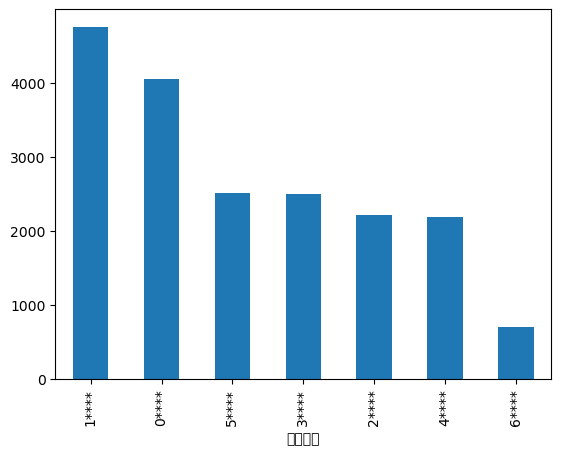

In [6]:
import matplotlib.pyplot as plt
df.우편번호.value_counts().plot(kind='bar')


## 라운딩

In [7]:
# 라운딩 
df.대출금액.round(-1)

0         250
1         340
2          30
3         130
4          30
5          30
6         600
7         370
8          30
9         230
10        220
11        130
12         30
13         30
14        430
15         30
16        370
17        180
18        250
19        150
20        120
21       1490
22        180
23        150
24        150
25        220
26        200
27         30
28        440
29         30
30         90
31        200
32         30
33         30
34        370
35        100
36        270
37         30
38         40
39         30
40        180
41        160
42        120
43         30
44         30
45         30
46       2760
47        260
48        220
49         70
         ... 
18872      90
18873      30
18874      70
18875     260
18876     240
18877     580
18878     300
18879     350
18880      30
18881      30
18882     150
18883      30
18884      50
18885     190
18886     490
18887     130
18888      30
18889      30
18890     200
18891     130
18892 

## 수치형 데이터 통계 및 시각화

- Quartile : 1/4 단위로 자른 0%, 25%, 50%, 75% , 100% 의 값  
- Quantile : 100% 중에 어느 값
- IQR : 25~75% 의 범위 => 극단값에 영향을 받지 않는 중간 50% 의 범위를 의미

In [8]:
# 대출 금액 quantile

print (df.대출금액.quantile( [0, 0.25, 0.5, 0.75, 1]))
print (df.대출금액.quantile(0.99))

0.00       33.0
0.25       33.0
0.50      110.0
0.75      214.0
1.00    48610.0
Name: 대출금액, dtype: float64
1028.0


{'whiskers': [<matplotlib.lines.Line2D at 0x166974910>,
 'caps': [<matplotlib.lines.Line2D at 0x166974b90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1669747d0>],
 'medians': [<matplotlib.lines.Line2D at 0x166974e10>],
 'fliers': [<matplotlib.lines.Line2D at 0x166974f50>],
 'means': []}

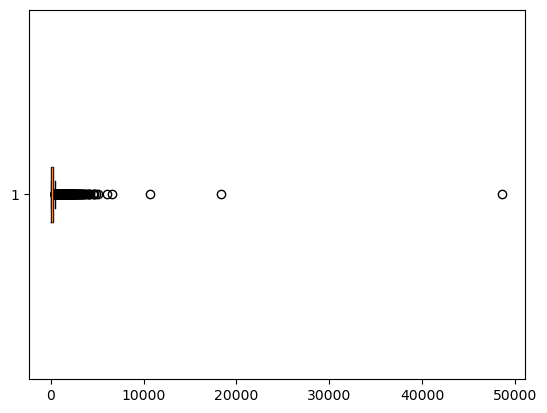

In [9]:
# box plot 

plt.boxplot (df.대출금액, vert=False)

In [10]:
# 1. [통계적 기법(IQR)을 이용한 이상치(Outlier) 경곗값 계산] => 상하단 코딩의 기준 금액으로 사용

# (참고) IQR (사분위 범위) = Q3 - Q1 : 데이터의 중간 50%가 모여있는 구간의 길이
# QR 길이의 1.5배 이상 벗어난 값을 Outlier 로 판별

Q1=df.대출금액.quantile(.25)
Q3=df.대출금액.quantile(.75)
u_border= Q3+(Q3-Q1)*1.5
l_border= Q1-(Q3-Q1)*1.5

print(f"하단 코딩 기준선: {l_border:.2f}")
print(f"상단 코딩 기준선: {u_border:.2f}")

#상단 코딩 처리 대상자(초고액 대출자) 데이터만 필터링
df[ df.대출금액 > u_border]

하단 코딩 기준선: -238.50
상단 코딩 기준선: 485.50


,성별,나이,우편번호,가입기간,대출건수,문의건수,보유계좌수,연체금액,대출금액,예금잔액,적금잔액
6,2,53,0****,11,3,8,1,0,595,115,293
21,1,39,1****,14,4,9,3,0,1494,26,211
46,2,47,6****,10,3,7,1,0,2762,113,191
78,1,45,1****,12,5,10,3,0,544,83,289
106,1,55,4****,14,5,10,1,0,1211,56,224
128,2,45,5****,12,5,12,2,0,1106,28,130
163,1,42,0****,16,7,8,1,77,1003,34,208
175,2,53,3****,18,9,13,1,85,2223,23,362
181,1,45,1****,18,9,10,1,0,491,35,206
185,2,45,5****,11,4,9,8,0,559,24,264


## 상하단 코딩

/var/folders/q4/h7wn7vns2jz5n1tz92rsqkn00000gn/T/ipykernel_27593/3887752969.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '485.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[ df.대출금액 > u_border, '대출금액'] = u_border


{'whiskers': [<matplotlib.lines.Line2D at 0x1669dc550>,
 'caps': [<matplotlib.lines.Line2D at 0x1669dc7d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1669dc410>],
 'medians': [<matplotlib.lines.Line2D at 0x1669dca50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1669dcb90>],
 'means': []}

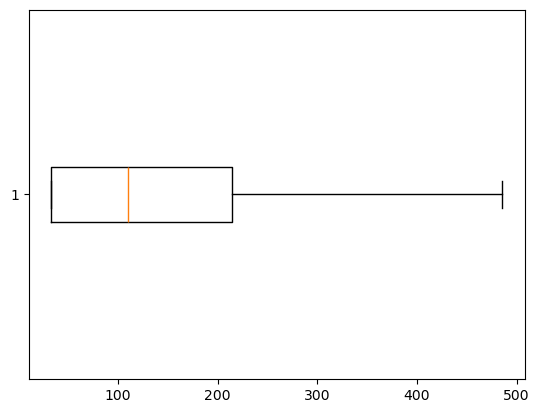

In [11]:
# outlier 기준으로 
df.loc[ df.대출금액 > u_border, '대출금액'] = u_border

plt.boxplot (df.대출금액, vert=False)

In [12]:
# 2. percentile 기준으로 : 상위 1% 위치에 있는 사람의 금액 이상을 묶음

df=pd.read_csv ("data_org.csv", encoding="cp949", dtype={"식별번호":str , "성별": str, "우편번호":str})

uv=df.대출금액.quantile(0.99) #상단 코딩 기준점
uv

np.float64(1028.0)

{'whiskers': [<matplotlib.lines.Line2D at 0x166d93110>,
 'caps': [<matplotlib.lines.Line2D at 0x166d93390>,
 'boxes': [<matplotlib.lines.Line2D at 0x166d92fd0>],
 'medians': [<matplotlib.lines.Line2D at 0x166d93610>],
 'fliers': [<matplotlib.lines.Line2D at 0x166d93750>],
 'means': []}

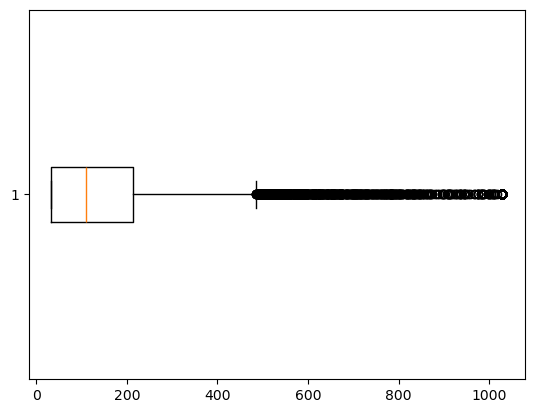

In [13]:
df.loc[ df.대출금액 > uv, '대출금액'] = uv

plt.boxplot (df.대출금액, vert=False)

# 익명처리




##  k 익명성

In [14]:
import pandas as pd

# 파일 로딩
df=pd.read_csv ("data_org.csv", encoding="cp949", dtype={"식별번호":str , "성별": str, "우편번호":str})
df

,식별번호,성별,나이,우편번호,가입기간,대출건수,문의건수,보유계좌수,연체금액,대출금액,예금잔액,적금잔액
0,56586729,2,62,53015,11,3,9,3,0,247,43,264
1,82351459,2,35,52319,12,5,10,2,0,335,40,113
2,89060200,2,10,04534,10,3,5,5,0,33,20,30
3,21151877,1,51,41535,10,3,8,8,0,128,27,214
4,76275783,2,67,38186,11,3,8,1,0,33,28,265
5,56315627,2,55,04534,10,3,5,5,0,33,20,30
6,34674716,2,53,06627,11,3,8,1,0,595,115,293
7,33851109,1,39,06797,10,3,10,5,59,367,45,203
8,87812632,1,43,11922,10,3,6,11,0,33,125,135
9,10772216,2,52,35212,12,5,12,2,0,233,22,211


## 준식별자를 구분하여 k 값 측정

In [15]:
# K 측정 
pd.set_option('display.max_rows',100)
pd.set_option('display.min_rows',None)

# 성별, 나이, 우편번호가 완전히 똑같은 사람들끼리 그룹 = 동치클래스 확인 = k 값
print("범주화 전 최소 K값:", df.groupby(by=['성별', '나이', '우편번호']).size().min())

범주화 전 최소 K값: 1


In [16]:
# k=1 , 즉 모두 식별가능한 상태

# K 만족을 위한 범주화, 마스킹, 레코드 삭제 과정을 진행
# 나이 = 10세 단위

df['나이'] = df['나이'].round(-1) #반올림 : 24세 => 20 / 25세 => 30
print("\n--- 처리된 나이 샘플 ---")
print(df['나이'].head())

print("\n나이 범주화 후 최소 K값:", df.groupby(by=['성별', '나이', '우편번호']).size().min())


--- 처리된 나이 샘플 ---
0    60
1    40
2    10
3    50
4    70
Name: 나이, dtype: int64

나이 범주화 후 최소 K값: 1


In [17]:
# K 및 동치 클래스 개수(EC 갯수), 크기 파악

def eval_K ( df ) :
    print ( "k값 : ", df.groupby(by=['성별', '나이', '우편번호']).size().min()    )
    print ("EC 갯수 : ", df.groupby(by=['성별', '나이', '우편번호']).size().count()  )
    print ("EC 사이즈 별 개수\n", df.groupby(by=['성별', '나이', '우편번호']).size().value_counts() )    
    
eval_K(df)

# EC 사이즈별 개수
# 1 9717 => k=1 (한그룹안에 1명)이 9717 개 존재
# 2 2361 => k=2 (한그룹안에 2명)이 묶여있는 그룹이 2361개 존재

k값 :  1
EC 갯수 :  13265
EC 사이즈 별 개수
 1     9717
2     2361
3      725
4      261
5      106
6       41
7       23
8       16
9        6
10       3
11       2
35       1
12       1
32       1
14       1
Name: count, dtype: int64


In [18]:
#  우편번호 mask 앞 3자리 

#df['우편번호']= df['우편번호'][ :3]+"**"
df['우편번호']=df['우편번호'].apply( lambda x : x[:1]+"****")
print (df['우편번호'])

eval_K(df)

0        5****
1        5****
2        0****
3        4****
4        3****
5        0****
6        0****
7        0****
8        1****
9        3****
10       6****
11       2****
12       3****
13       1****
14       2****
15       2****
16       6****
17       0****
18       2****
19       2****
20       4****
21       1****
22       5****
23       3****
24       2****
25       2****
26       0****
27       0****
28       1****
29       1****
30       2****
31       6****
32       3****
33       3****
34       0****
35       0****
36       0****
37       5****
38       3****
39       2****
40       3****
41       1****
42       6****
43       1****
44       4****
45       1****
46       6****
47       1****
48       6****
49       1****
         ...  
18872    1****
18873    6****
18874    0****
18875    1****
18876    4****
18877    3****
18878    4****
18879    3****
18880    1****
18881    3****
18882    0****
18883    5****
18884    0****
18885    2****
18886    5****
18887    1

In [19]:
# 나이 하나의 분포를 봄

df["나이"].value_counts()

나이
40    5375
50    5057
60    4234
30    2191
70    1311
80     498
20     216
90      39
10       1
Name: count, dtype: int64

In [20]:
#  나이 상하단 코딩

df.loc[ df.나이 > 70, '나이'] =70
df.loc[ df.나이 < 30, '나이'] =30
df["나이"].value_counts()

나이
40    5375
50    5057
60    4234
30    2408
70    1848
Name: count, dtype: int64

In [21]:
#우편번호 범주화
#나이 범주화, 상하단 코딩
# 대출금액 상하단 코딩

print (df.head())
print (eval_K(df))

       식별번호 성별  나이   우편번호  가입기간  대출건수  문의건수  보유계좌수  연체금액  대출금액  예금잔액  적금잔액
0  56586729  2  60  5****    11     3     9      3     0   247    43   264
1  82351459  2  40  5****    12     5    10      2     0   335    40   113
2  89060200  2  30  0****    10     3     5      5     0    33    20    30
3  21151877  1  50  4****    10     3     8      8     0   128    27   214
4  76275783  2  70  3****    11     3     8      1     0    33    28   265
k값 :  22
EC 갯수 :  70
EC 사이즈 별 개수
 393    2
184    2
144    1
191    1
176    1
53     1
771    1
928    1
354    1
402    1
442    1
369    1
147    1
658    1
824    1
328    1
429    1
282    1
450    1
118    1
518    1
606    1
347    1
397    1
305    1
434    1
89     1
195    1
256    1
140    1
240    1
112    1
241    1
375    1
22     1
226    1
265    1
100    1
84     1
93     1
97     1
31     1
478    1
489    1
220    1
217    1
246    1
204    1
69     1
351    1
474    1
235    1
80     1
234    1
249    1
67     1
338    1
385

In [22]:
# 레코드 삭제 방법 
#df=df.drop(labels=[2, 12316], axis=0) # label= row번호 나열 

In [23]:
# size 1인  EC보기 
df.groupby(by=['성별', '나이', '우편번호']).filter(lambda x : len(x)==1   )

,식별번호,성별,나이,우편번호,가입기간,대출건수,문의건수,보유계좌수,연체금액,대출금액,예금잔액,적금잔액


In [24]:
# 레코드 삭제 방법 
df.loc[[2, 12316]]
df=df.drop(labels=[2, 12316], axis=0) # label= row번호 나열 

# 총계 처리 

In [25]:
df.sort_values (by =['성별', '나이', '우편번호'])

,식별번호,성별,나이,우편번호,가입기간,대출건수,문의건수,보유계좌수,연체금액,대출금액,예금잔액,적금잔액
149,70703629,1,30,0****,9,2,5,1,0,33,20,30
160,40648781,1,30,0****,11,4,10,2,0,167,21,105
166,70582454,1,30,0****,11,3,9,3,0,123,96,146
211,84349106,1,30,0****,11,4,9,1,85,179,24,78
241,85358716,1,30,0****,13,6,9,1,0,357,65,133
292,62353773,1,30,0****,10,3,5,4,0,33,20,30
297,56728939,1,30,0****,11,4,6,1,73,33,34,44
386,15893509,1,30,0****,11,3,9,2,0,237,65,120
670,83104079,1,30,0****,10,3,8,3,0,201,80,128
681,37776177,1,30,0****,9,2,5,1,0,33,20,30


In [26]:
print(df.select_dtypes(include=['object']).columns)

Index(['식별번호', '성별', '우편번호'], dtype='object')


In [27]:
# 총계 처리

df.groupby(by=['성별', '나이', '우편번호']).mean(numeric_only=True)

가입기간      대출건수      문의건수     보유계좌수       연체금액        대출금액  \
성별 나이 우편번호                                                                    
1  30 0****  10.716312  3.556738  7.411348  2.177305  19.099291  158.698582   
      1****  10.765487  3.557522  7.389381  2.252212  22.022124  137.491150   
      2****  10.990000  3.750000  7.210000  2.050000  24.950000  154.950000   
      3****  10.642857  3.476190  7.428571  2.297619  20.666667  148.845238   
      4****  10.935484  3.741935  7.903226  1.903226  21.559140  141.086022   
      5****  10.659794  3.525773  7.659794  1.927835  25.134021  162.752577   
      6****  10.451613  3.322581  7.612903  2.161290  18.645161  173.129032   
   40 0****  11.284519  3.910042  8.474895  2.893305  23.512552  212.336820   
      1****  11.321063  3.912065  8.429448  2.568507  21.269939  226.997955   
      2****  11.181818  3.827273  8.240909  2.568182  21.295455  182.268182   
      3****  11.396313  3.995392  8.281106  2.497696  18.594470  204.658986   
      4****  11.215447  3.930894  8.670732  2.532520  20.280488  248.016260   
      5****  11.200980  3.808824  8.259804  2.509804  18.318627  163.303922   
      6****  11.275362  3.913043  8.579710  2.289855  27.623188  201.579710   
   50 0****  11.376068  4.017094  8.185185  3.387464  25.478632  207.350427   
      1****  11.394515  3.991561  8.428270  2.938819  20.514768  197.814346   
      2****  11.362264  3.943396  8.267925  2.928302  22.796226  188.592453   
      3****  11.174468  3.825532  8.187234  3.068085  21.204255  173.948936   
      4****  11.461538  4.000000  8.542735  2.974359  22.572650  179.551282   
      5****  11.208835  3.819277  8.160643  2.755020  22.100402  156.489960   
      6****  11.268657  3.895522  8.835821  2.388060  22.671642  259.507463   
   60 0****  11.139053  3.786982  8.071006  3.467456  24.931953  152.213018   
      1****  11.233766  3.836364  8.080519  3.103896  21.641558  152.007792   
      2****  11.469697  4.000000  7.873737  3.358586  23.949495  138.378788   
      3****  10.927778  3.533333  7.500000  3.305556  19.772222  116.255556   
      4****  11.030928  3.644330  8.051546  2.922680  21.654639  134.432990   
      5****  11.092391  3.717391  7.413043  2.777174  21.043478  107.467391   
      6****  10.932203  3.457627  8.186441  3.440678  19.677966  126.881356   
   70 0****  10.690265  3.398230  7.159292  4.911504  28.929204  103.141593   
      1****  10.604520  3.305085  6.666667  3.774011  22.525424   87.141243   
      2****  10.406250  3.171875  5.843750  3.906250  16.906250   56.234375   
      3****  10.425287  3.183908  5.942529  4.425287  21.827586   58.632184   
      4****  10.653333  3.280000  6.280000  4.360000  28.026667   54.680000   
      5****  10.412500  3.087500  5.800000  4.462500  15.575000   58.437500   
      6****  10.590909  3.272727  6.227273  4.045455  18.545455   68.363636   
2  30 0****  10.889518  3.631728  7.277620  1.983003  20.957507  150.033994   
      1****  10.969466  3.689567  7.147583  2.007634  22.190840  147.783715   
      2****  10.833333  3.618056  7.097222  2.256944  19.861111  133.381944   
      3****  10.968586  3.764398  7.219895  1.921466  18.324607  139.596859   
      4****  10.847826  3.603261  7.315217  2.065217  23.951087  142.326087   
      5****  10.914773  3.590909  7.318182  1.892045  20.130682  160.664773   
      6****  11.113208  3.867925  6.943396  2.471698  29.660377  138.301887   
   40 0****  11.591440  4.120623  8.247730  2.405966  22.027237  227.320363   
      1****  11.450431  3.988147  8.280172  2.322198  20.382543  198.808190   
      2****  11.619403  4.121891  8.181592  2.393035  23.213930  200.654229   
      3****  11.502262  3.988688  8.266968  2.266968  18.355204  198.638009   
      4****  11.468835  4.081301  8.303523  2.409214  23.981030  197.081301   
      5****  11.592875  4.081425  8.134860  2.430025  21.035623  188.671756   
      6****  11.394558  3.870748  8.115646  2.299320  17.510204  240

In [28]:
# 기술통계

dfg = df.groupby(by=['성별', '나이', '우편번호'])[['대출금액', '예금잔액', '적금잔액']].agg(['count', 'mean', 'std', 'min', 'max'])
print (dfg)

             대출금액                                      예금잔액             \
            count        mean          std min    max count       mean   
성별 나이 우편번호                                                               
1  30 0****   282  158.698582   185.266005  33   1899   282  44.361702   
      1****   226  137.491150   127.380767  33    837   226  42.057522   
      2****   100  154.950000   314.188401  33   3087   100  44.460000   
      3****    84  148.845238   166.257348  33   1139    84  43.916667   
      4****    93  141.086022   116.864438  33    533    93  43.387097   
      5****    97  162.752577   201.965758  33   1352    97  39.567010   
      6****    31  173.129032   182.279591  33    733    31  49.580645   
   40 0****   478  212.336820   215.525115  33   2328   478  60.558577   
      1****   489  226.997955   356.760272  33   6001   489  59.036810   
      2****   220  182.268182   188.783067  33   1452   220  59.913636   
      3****   217  204.658986   270.36

In [29]:
# csv 로 저장 
dfg.to_csv("data_agg.csv",  encoding="cp949")

# L-다양성 계량

In [30]:
# EC 별로 특정 필드의 unique 값 조회
print("▶ 그룹별 인원수(K값) 확인")
df.groupby(by=['성별', '나이', '우편번호']).size()

▶ 그룹별 인원수(K값) 확인


성별  나이  우편번호 
1   30  0****    282
        1****    226
        2****    100
        3****     84
        4****     93
        5****     97
        6****     31
    40  0****    478
        1****    489
        2****    220
        3****    217
        4****    246
        5****    204
        6****     69
    50  0****    351
        1****    474
        2****    265
        3****    235
        4****    234
        5****    249
        6****     67
    60  0****    338
        1****    385
        2****    198
        3****    180
        4****    194
        5****    184
        6****     59
    70  0****    113
        1****    177
        2****     64
        3****     87
        4****     75
        5****     80
        6****     22
2   30  0****    353
        1****    393
        2****    144
        3****    191
        4****    184
        5****    176
        6****     53
    40  0****    771
        1****    928
        2****    402
        3****    442
        4****    369

In [31]:
# EC 별로 특정 필드의 unique 갯수 조회 
print("\n▶ 그룹별 보유계좌수 종류(다양성) 확인")
df.groupby(by=['성별', '나이', '우편번호']).보유계좌수.nunique()


▶ 그룹별 보유계좌수 종류(다양성) 확인


성별  나이  우편번호 
1   30  0****    10
        1****    11
        2****     9
        3****     9
        4****     8
        5****     7
        6****     6
    40  0****    16
        1****    15
        2****    10
        3****    14
        4****    14
        5****    11
        6****    10
    50  0****    16
        1****    16
        2****    14
        3****    13
        4****    17
        5****    14
        6****    10
    60  0****    19
        1****    15
        2****    14
        3****    17
        4****    15
        5****    11
        6****    10
    70  0****    16
        1****    17
        2****    12
        3****    14
        4****    13
        5****    16
        6****     9
2   30  0****    11
        1****    12
        2****    11
        3****     9
        4****    10
        5****     8
        6****     9
    40  0****    15
        1****    13
        2****    13
        3****    12
        4****    13
        5****    16
        6****    10
    50

In [32]:
# EC 별로 특정 필드의 unique 갯수 중 가장 작은것 => L 값
print(f"\n▶ 우리 데이터베이스의 '적금잔액' 최소 L값은")
min ( df.groupby(by=['성별', '나이', '우편번호']).적금잔액.nunique())


▶ 우리 데이터베이스의 '적금잔액' 최소 L값은


13